<a href="https://colab.research.google.com/github/DilakshanRahul12/CM2604/blob/RF/RF_bank_additional_without_unknowns%26outliers_handled.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
dataset = '/content/drive/MyDrive/CM2604/dataset/bank-additional/bank-additional-full.csv'
df = pd.read_csv(dataset, sep=';')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
df_non = df.replace("unknown", None).dropna()

In [ ]:
numerical_columns = ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

### outliers

Adjest duration

In [ ]:
df_dur = df_non[df_non['duration'] < 814].copy()
df_dur.shape

(29243, 21)

age

In [ ]:
df_dur['age'] = df_dur['age'].apply(lambda x: 66 if x > 66 else x)

campaign

In [ ]:
df_dur['campaign'] = np.log1p(df_dur['campaign'])

pday

In [ ]:
# Define a function to categorize 'pdays'
def categorize_pdays(pdays):
    if 0 <= pdays <= 30:
        return 'recently contacted'
    elif 31 <= pdays <= 90:
        return 'contacted few months ago'
    elif 91 <= pdays <= 998:
        return 'contacted long ago'
    elif pdays == 999:
        return 'not contacted'

numerical_columns.remove('pdays')

# Apply the function to create the new categorical feature
df_dur['pdays'] = df_dur['pdays'].apply(categorize_pdays)

previous

In [ ]:
df_dur['previous'] = np.log1p(df_dur['previous'])

In [ ]:
df_handled = df_dur.copy()

In [ ]:
df_handled['duration'] = np.log1p(df_handled['duration'])  # log(1 + x) for duration

### Encode

In [ ]:
df_encoded1 = df_handled.copy()

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoders and store mappings
label_encoders = {}
mappings = {}

# Iterate through categorical columns
for column in df_encoded1.select_dtypes(include=['object']):
    le = LabelEncoder()
    df_encoded1[column] = le.fit_transform(df_encoded1[column])
    label_encoders[column] = le
    mappings[column] = dict(zip(le.classes_, le.transform(le.classes_)))

# Display the mappings
"""
for column, mapping in mappings.items():
    print(f"Mappings for column '{column}':")
    print(mapping)
    print("---")
"""

'\nfor column, mapping in mappings.items():\n    print(f"Mappings for column \'{column}\':")\n    print(mapping)\n    print("---")\n'

### Feature Eng

In [ ]:
df_feat = df_encoded1.copy()

In [ ]:
# from sklearn.decomposition import PCA

# pca = PCA(n_components=1)
# economic_features1 = df_feat[['emp.var.rate', 'cons.price.idx', 'cons.conf.idx']]
# df_feat['economic1'] = pca.fit_transform(economic_features1)
# print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")

Explained Variance Ratio: [0.88943489]


In [ ]:
# economic_features2 = df_feat[['euribor3m', 'nr.employed']]
# df_feat['economic2'] = pca.fit_transform(economic_features2)
# print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")

Explained Variance Ratio: [0.99993998]


In [ ]:
df_dt = df_feat.copy()
# df_dt.drop('emp.var.rate',axis = 1,inplace = True)
# df_dt.drop('cons.price.idx',axis = 1,inplace = True)
# df_dt.drop('cons.conf.idx',axis = 1,inplace = True)
# df_dt.drop('euribor3m',axis = 1,inplace = True)
# df_dt.drop('nr.employed',axis = 1,inplace = True)

In [ ]:
df_dt.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,3,1,0,0,0,0,1,6,1,...,0.693147,0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,1,0,1,6,1,...,0.693147,0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,1,0,0,0,1,6,1,...,0.693147,0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,3,0,0,1,1,6,1,...,0.693147,0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
6,59,0,1,5,0,0,0,1,6,1,...,0.693147,0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0


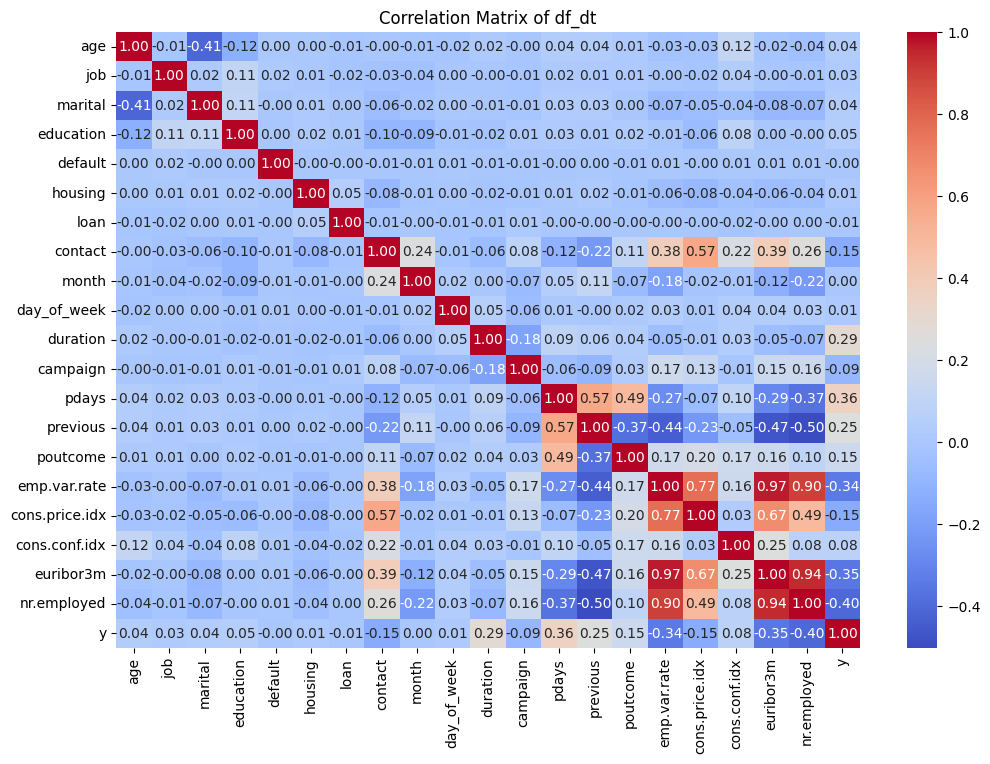

In [ ]:
correlation_matrix = df_dt.corr()

# Plot a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix of df_dt")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Assuming df_dt is your preprocessed DataFrame and 'y' is your target variable column
X = df_dt.drop('y', axis=1)
y = df_dt['y']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train a RandomForestClassifier
#rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42) # You can adjust hyperparameters
rf_classifier = RandomForestClassifier()
rf_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))

Accuracy: 0.9197537900376154
              precision    recall  f1-score   support

           0       0.94      0.97      0.96      7856
           1       0.66      0.49      0.56       917

    accuracy                           0.92      8773
   macro avg       0.80      0.73      0.76      8773
weighted avg       0.91      0.92      0.91      8773



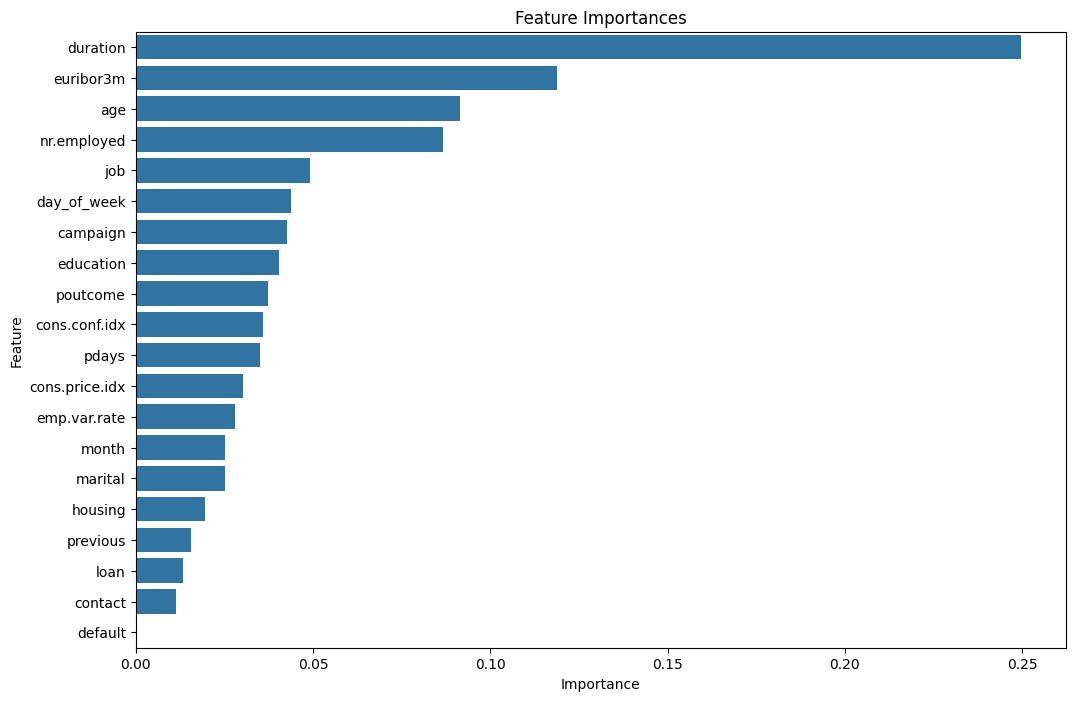

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
importances = rf_classifier.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Create a bar plot
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for the RandomForestClassifier
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20,30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the GridSearchCV object
grid_search = GridSearchCV(estimator=rf_classifier, param_grid=param_grid, cv=5, scoring='accuracy')

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Print the best hyperparameters and the corresponding accuracy score
print("Best hyperparameters:", grid_search.best_params_)
print("Best accuracy score:", grid_search.best_score_)

# Evaluate the best model on the test set
best_rf_classifier = grid_search.best_estimator_
y_pred = best_rf_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of best model on test set: {accuracy}")
print(classification_report(y_test, y_pred))

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split

X = df_dt.drop('y', axis=1)
y = df_dt['y']

# Address class imbalance using RandomOverSampler
oversampler = RandomOverSampler(random_state=42)
X_resampled, y_resampled = oversampler.fit_resample(X, y)


X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Initialize and train the BaggingClassifier with a DecisionTreeClassifier as the base estimator
# In older versions of scikit-learn, the 'base_estimator' argument might not be available.
# Instead, you might need to use the 'estimator' argument.
bagging_model = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42) # Adjust n_estimators as needed
bagging_model.fit(X_train, y_train)

# Make predictions and evaluate the model (example using accuracy)
from sklearn.metrics import accuracy_score
y_pred = bagging_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of Bagging Classifier: {accuracy}")

# You can further evaluate the model with other metrics like precision, recall, F1-score, etc.
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for the RandomForestClassifier
param_grid = {
    'n_estimators': [50, 100, 200,300],
    'max_depth': [None, 10, 20,30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the GridSearchCV object
grid_search = GridSearchCV(estimator=rf_classifier, param_grid=param_grid, cv=5, scoring='accuracy')

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Print the best hyperparameters and the corresponding accuracy score
print("Best hyperparameters:", grid_search.best_params_)
print("Best accuracy score:", grid_search.best_score_)

# Evaluate the best model on the test set
best_rf_classifier = grid_search.best_estimator_
y_pred = best_rf_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of best model on test set: {accuracy}")
print(classification_report(y_test, y_pred))